# Function Transformer

## Log Transform  Reciprocal Transform  Square Root Transform

In [44]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import scipy.stats as stats

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import FunctionTransformer   # IMP
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

In [45]:
df_input = pd.read_csv(r"D:\AI-engineer Study\CampusX\ML CampusX\16. Data Understanding and EDA\EDA using Univariate Analysis\train.csv", usecols=['Age', 'Fare', 'Survived'])
df_input.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [46]:
df_input.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [47]:
df_input['Age'] = df_input['Age'].fillna(df_input['Age'].mean())

In [48]:
df_input.isnull().sum()

Survived    0
Age         0
Fare        0
dtype: int64

In [49]:
X = df_input.iloc[:,1:3]
y = df_input.iloc[:,0]


In [50]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

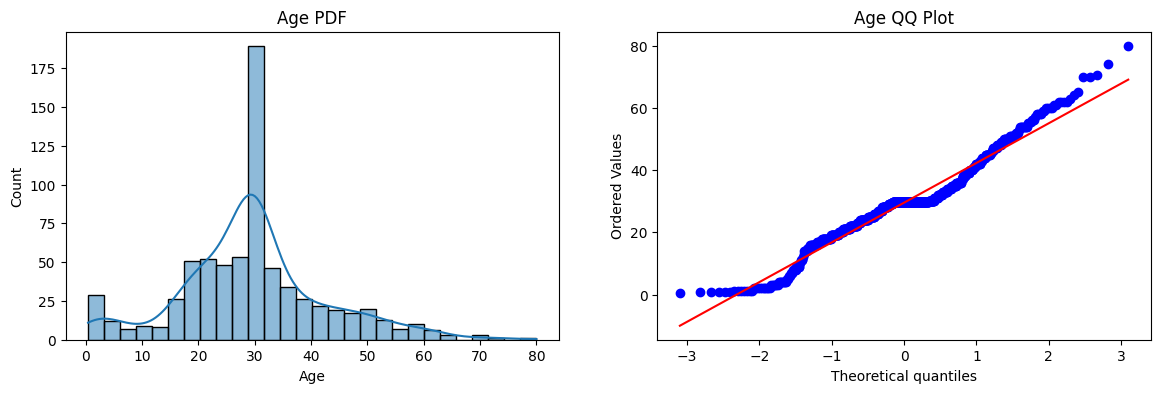

In [51]:
plt.figure(figsize=(14, 4))

plt.subplot(121)
sns.histplot(X_train['Age'], kde=True)
plt.title('Age PDF')

plt.subplot(122)
stats.probplot(X_train['Age'], dist='norm', plot=plt)
plt.title('Age QQ Plot')

plt.show()

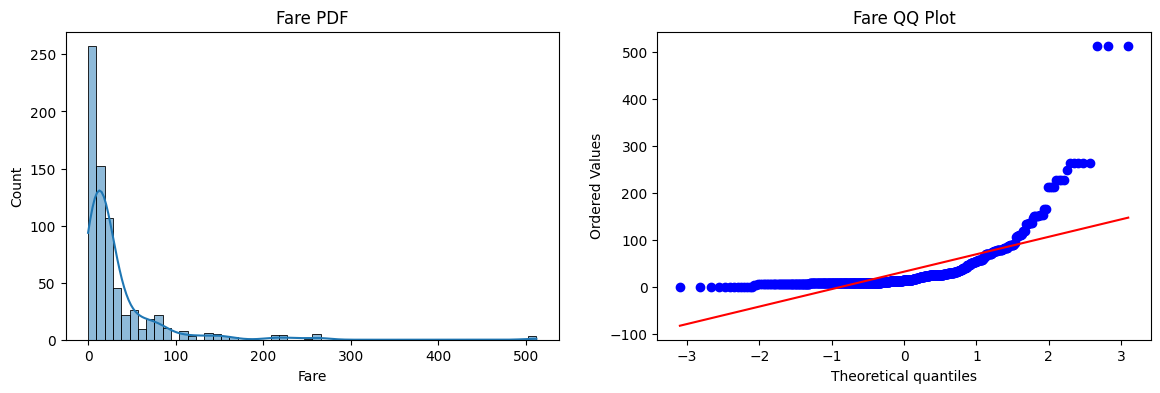

In [52]:
plt.figure(figsize=(14, 4))

plt.subplot(121)
sns.histplot(X_train['Fare'], kde=True)
plt.title('Fare PDF')

plt.subplot(122)
stats.probplot(X_train['Fare'], dist='norm', plot=plt)
plt.title('Fare QQ Plot')

plt.show()

In [53]:
lr_model = LogisticRegression()
dt_model = DecisionTreeClassifier()

In [54]:
lr_model.fit(X_train, y_train)
dt_model.fit(X_train, y_train)

lr_y_pred = lr_model.predict(X_test)
dt_y_pred = dt_model.predict(X_test)

print("Accuracy score LR: ",accuracy_score(y_test, lr_y_pred))
print("Accuracy score DT: ",accuracy_score(y_test, dt_y_pred))

Accuracy score LR:  0.6480446927374302
Accuracy score DT:  0.659217877094972


## Now we are using Function transformer

In [55]:
trf = FunctionTransformer(func=np.log1p)

In [56]:
X_train_transform = trf.fit_transform(X_train)
X_test_transform = trf.transform(X_test)

In [57]:
lr_model = LogisticRegression()
dt_model = DecisionTreeClassifier()

In [58]:
lr_model.fit(X_train_transform, y_train)
dt_model.fit(X_train_transform, y_train)

lr_y_pred = lr_model.predict(X_test_transform)
dt_y_pred = dt_model.predict(X_test_transform)

print("Accuracy score LR: ",accuracy_score(y_test, lr_y_pred))
print("Accuracy score DT: ",accuracy_score(y_test, dt_y_pred))

Accuracy score LR:  0.6815642458100558
Accuracy score DT:  0.6815642458100558


In [59]:
X_transformed = trf.fit_transform(X)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("LR",np.mean(cross_val_score(clf,X_transformed,y,scoring='accuracy',cv=10)))
print("DT",np.mean(cross_val_score(clf2,X_transformed,y,scoring='accuracy',cv=10)))

LR 0.678027465667915
DT 0.6577153558052434


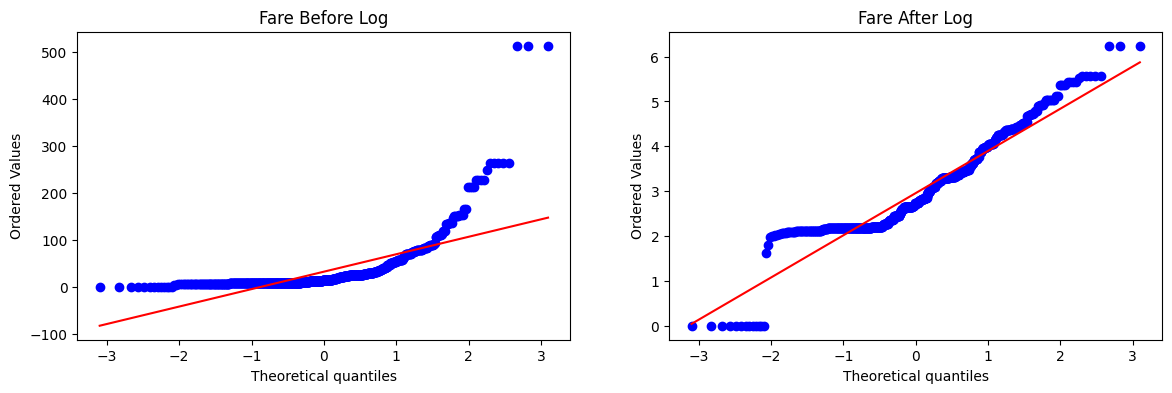

In [60]:
plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(X_train['Fare'], dist="norm", plot=plt)
plt.title('Fare Before Log')

plt.subplot(122)
stats.probplot(X_train_transform['Fare'], dist="norm", plot=plt)
plt.title('Fare After Log')

plt.show()

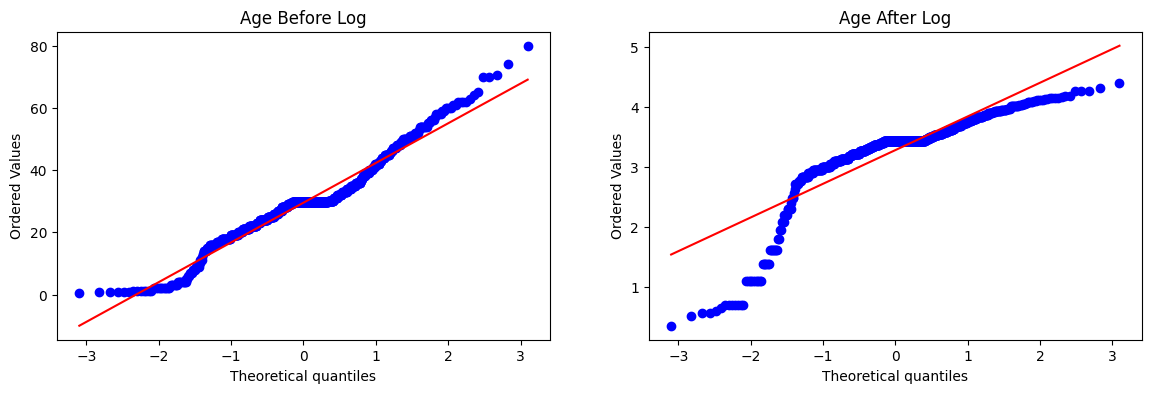

In [61]:
plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(X_train['Age'], dist="norm", plot=plt)
plt.title('Age Before Log')

plt.subplot(122)
stats.probplot(X_train_transform['Age'], dist="norm", plot=plt)
plt.title('Age After Log')

plt.show()

In [62]:
trf2 = ColumnTransformer([
    ('log', FunctionTransformer(func=np.log1p), ['Fare'])
], remainder='passthrough')

In [66]:
X_train_transform_2 = trf2.fit_transform(X_train)
X_test_transform_2 = trf2.transform(X_test)

In [67]:
lr_model.fit(X_train_transform_2, y_train)
dt_model.fit(X_train_transform_2, y_train)

lr_y_pred = lr_model.predict(X_test_transform_2)
dt_y_pred = dt_model.predict(X_test_transform_2)

print("Accuracy score LR: ",accuracy_score(y_test, lr_y_pred))
print("Accuracy score DT: ",accuracy_score(y_test, dt_y_pred))

Accuracy score LR:  0.6703910614525139
Accuracy score DT:  0.659217877094972


In [68]:
X_transformed2 = trf2.fit_transform(X)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("LR",np.mean(cross_val_score(clf,X_transformed2,y,scoring='accuracy',cv=10)))
print("DT",np.mean(cross_val_score(clf2,X_transformed2,y,scoring='accuracy',cv=10)))

LR 0.6712609238451936
DT 0.6621972534332083


In [71]:
def apply_transform(transform):
    X = df_input.iloc[:,1:3]
    y = df_input.iloc[:,0]
    
    trf = ColumnTransformer([('log',FunctionTransformer(transform),['Fare'])],remainder='passthrough')
    
    X_trans = trf.fit_transform(X)
    
    clf = LogisticRegression()
    
    print("Accuracy",np.mean(cross_val_score(clf,X_trans,y,scoring='accuracy',cv=10)))
    
    plt.figure(figsize=(14,4))

    plt.subplot(121)
    stats.probplot(X['Fare'], dist="norm", plot=plt)
    plt.title('Fare Before Transform')

    plt.subplot(122)
    stats.probplot(X_trans[:,0], dist="norm", plot=plt)
    plt.title('Fare After Transform')

    plt.show()

Accuracy 0.6195131086142323


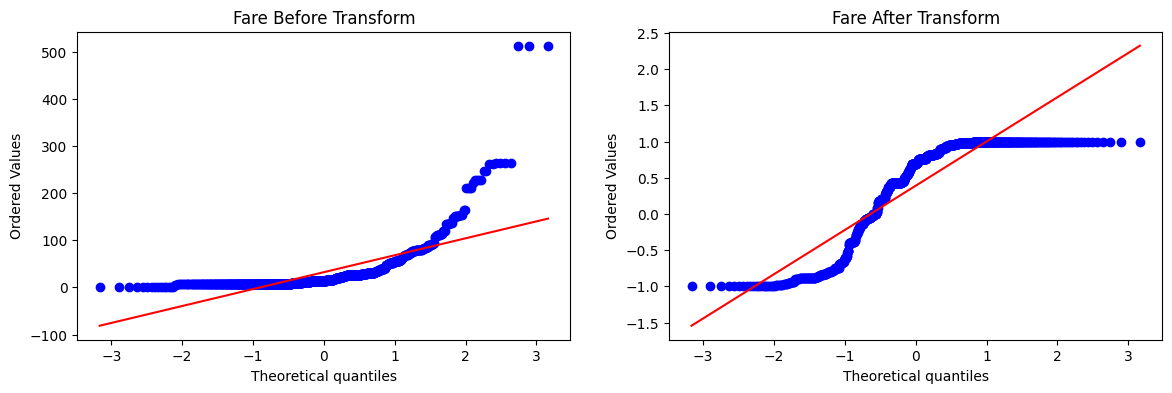

In [72]:
apply_transform(np.sin)

Accuracy 0.6431335830212235


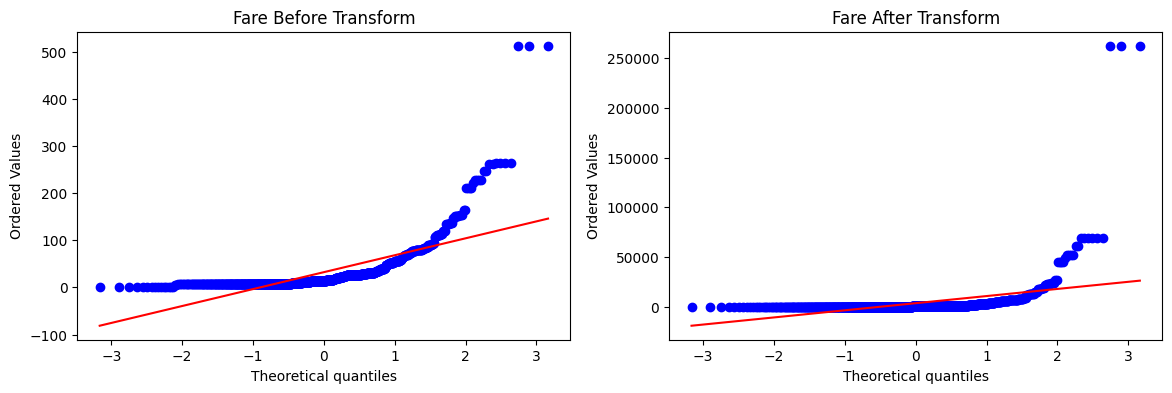

In [73]:
apply_transform(lambda x: x**2)